In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


In [2]:
!pip install xgboost lightgbm catboost -q
!pip install optuna -q
!pip install tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 10.6 MB/s eta 0:00:00


# 15 — Comprehensive Model Evaluation
### Early Sepsis Detection — Phase 17

Brings together every model trained so far (Phase 13-16) into one final
comparison: ROC curves, PR curves, calibration curves, and confusion
matrices side by side, plus a discussion of which metric matters most
for this specific clinical task.

**No model is declared "best" without this side-by-side evidence** — this
notebook is where that decision is actually made, using validation-set
results only (test set stays untouched until Phase 23's final check).


In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

from src import config
from src import target as tgt
from src import sequence_builder as sb
from src import evaluate as ev

npz = np.load(config.PROCESSED_DIR / "model_ready_arrays.npz")
X_val, y_val = npz["X_val"], npz["y_val"]


## 1. Reload every trained classical model and generate validation probabilities

In [4]:
classical_models = {
    "Logistic Regression": config.MODELS_DIR / "logistic_regression_baseline.pkl",
    "Decision Tree": config.MODELS_DIR / "decision_tree.pkl",
    "Random Forest": config.MODELS_DIR / "random_forest.pkl",
    "XGBoost": config.MODELS_DIR / "xgboost_model.pkl",
    "LightGBM (default)": config.MODELS_DIR / "lightgbm_model.pkl",
    "LightGBM (tuned)": config.MODELS_DIR / "lightgbm_tuned.pkl",
}

val_probs = {}
for name, path in classical_models.items():
    if path.exists():
        model = joblib.load(path)
        val_probs[name] = model.predict_proba(X_val)[:, 1]
    else:
        print(f"WARNING: {path} not found, skipping {name}")

# CatBoost saved in native format
import catboost as cb
cb_default_path = config.MODELS_DIR / "catboost_model.cbm"
cb_tuned_path = config.MODELS_DIR / "catboost_tuned.cbm"
if cb_default_path.exists():
    m = cb.CatBoostClassifier(); m.load_model(str(cb_default_path))
    val_probs["CatBoost (default)"] = m.predict_proba(X_val)[:, 1]
if cb_tuned_path.exists():
    m = cb.CatBoostClassifier(); m.load_model(str(cb_tuned_path))
    val_probs["CatBoost (tuned)"] = m.predict_proba(X_val)[:, 1]

print(f"Loaded {len(val_probs)} classical model probability sets.")


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Loaded 8 classical model probability sets.


## 2. Reload the LSTM model and reconstruct its validation sequences

In [5]:
raw_df = pd.read_parquet(config.INTERIM_LONG_PARQUET)
cleaned_df = pd.read_parquet(config.INTERIM_DIR / "sepsis_hourly_cleaned.parquet")
window_table = tgt.build_patient_level_window_labels(raw_df, config.PRIMARY_PREDICTION_WINDOW_HOURS)
sliced_cleaned = tgt.slice_features_to_window(cleaned_df, window_table)

split_lookup = pd.read_parquet(config.PROCESSED_DIR / "patient_split_assignment.parquet")
train_ids = split_lookup.loc[split_lookup["split"] == "train", config.PATIENT_ID_COL].to_numpy()
val_ids = split_lookup.loc[split_lookup["split"] == "val", config.PATIENT_ID_COL].to_numpy()

X_train_seq_raw, _ = sb.build_sequences(sliced_cleaned, train_ids, max_len=config.PRIMARY_PREDICTION_WINDOW_HOURS)
mean, std = sb.fit_sequence_scaler(X_train_seq_raw)  # must match Phase 16 exactly (deterministic)

X_val_seq_raw, _ = sb.build_sequences(sliced_cleaned, val_ids, max_len=config.PRIMARY_PREDICTION_WINDOW_HOURS)
X_val_seq = sb.fill_remaining_nans(sb.apply_sequence_scaler(X_val_seq_raw, mean, std))

lstm_path = config.MODELS_DIR / "lstm_model.keras"
if lstm_path.exists():
    lstm_model = tf.keras.models.load_model(lstm_path)
    val_probs["LSTM"] = lstm_model.predict(X_val_seq, verbose=0).ravel()
    print("LSTM predictions added.")


2026-09-15 07:46:56,153 | WARNING | src.target | Window=6h: excluding 965/40336 total patients (370 due to onset_hour<=1, 595 due to no data within the usable window despite a later onset).


LSTM predictions added.


## 3. Combined ROC and PR curves — all models together

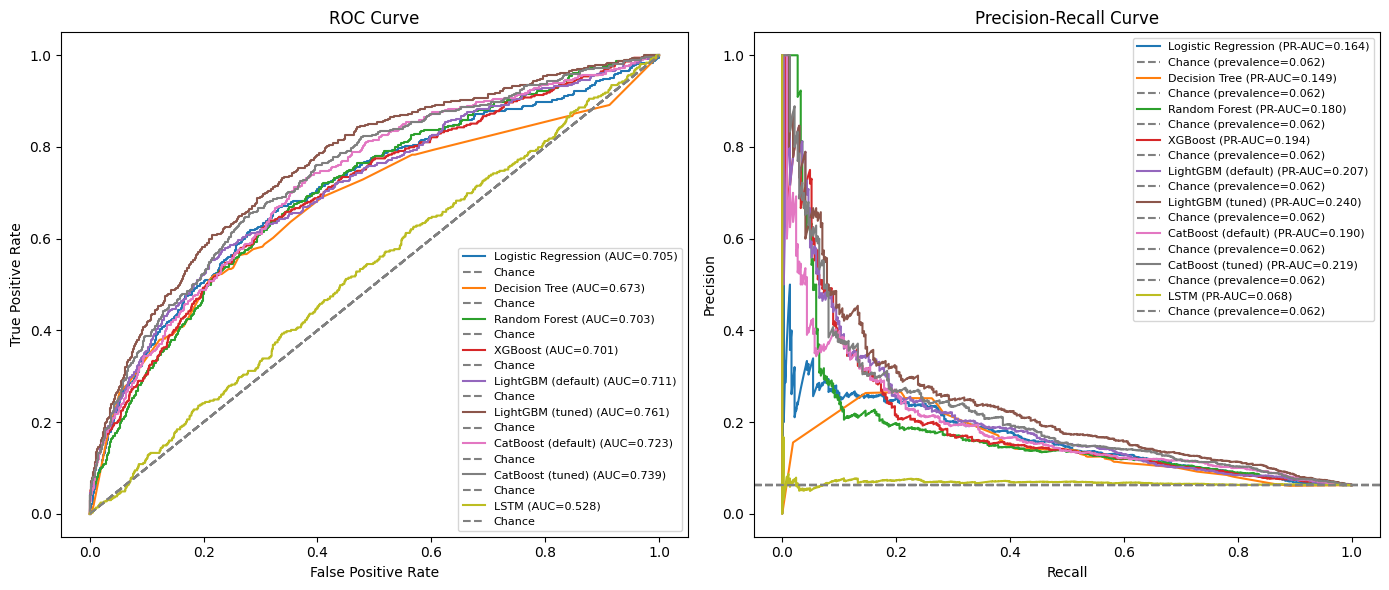

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for name, prob in val_probs.items():
    ev.plot_roc_curve(y_val, prob, model_name=name, ax=axes[0])
    ev.plot_pr_curve(y_val, prob, model_name=name, ax=axes[1])
axes[0].legend(fontsize=8, loc="lower right")
axes[1].legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "15_all_models_roc_pr_combined.png", dpi=150)
plt.show()


## 4. Calibration curves — all models together

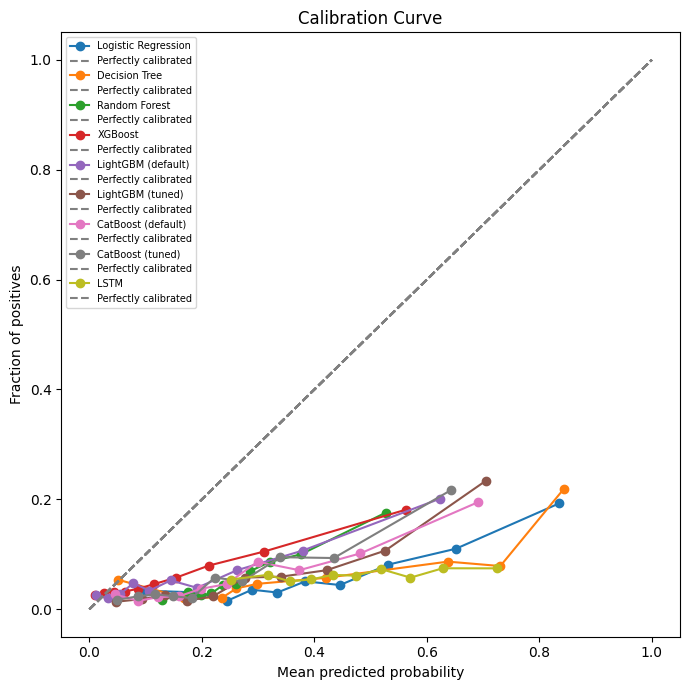

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
for name, prob in val_probs.items():
    ev.plot_calibration_curve(y_val, prob, model_name=name, ax=ax)
ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "15_all_models_calibration_combined.png", dpi=150)
plt.show()


## 5. Final comparison table (validation set), all models

In [8]:
rows = []
for name, prob in val_probs.items():
    m = ev.compute_metrics(y_val, prob, threshold=0.5)
    m["model"] = name
    rows.append(m)

final_comparison = pd.DataFrame(rows).sort_values("pr_auc", ascending=False)
final_comparison = final_comparison[["model", "roc_auc", "pr_auc", "precision",
                                       "recall_sensitivity", "specificity", "f1", "brier_score"]]
display(final_comparison)
final_comparison.to_csv(config.TABLES_DIR / "15_final_model_comparison.csv", index=False)


,model,roc_auc,pr_auc,precision,recall_sensitivity,specificity,f1,brier_score
5,LightGBM (tuned),0.760980,0.239682,0.179742,0.490515,0.850795,0.263081,0.126866
7,CatBoost (tuned),0.739415,0.218891,0.217755,0.352304,0.915643,0.269151,0.103397
4,LightGBM (default),0.710811,0.207377,0.218688,0.298103,0.929010,0.252294,0.087772
3,XGBoost,0.701030,0.194147,0.217910,0.197832,0.952673,0.207386,0.077902
6,CatBoost (default),0.722775,0.190043,0.168120,0.365854,0.879335,0.230375,0.118037
2,Random Forest,0.703486,0.179861,0.218750,0.151762,0.963873,0.179200,0.104408
0,Logistic Regression,0.705186,0.164364,0.130909,0.585366,0.740968,0.213967,0.198298
1,Decision Tree,0.673305,0.148882,0.118071,0.577236,0.712608,0.196042,0.194834
8,LSTM,0.528336,0.067911,0.069656,0.433604,0.613981,0.120030,0.240272


## 6. Which metric matters most for early sepsis detection? (discussion)

**Why NOT accuracy:** demonstrated in Phase 12 — a trivial "always negative"
classifier scores ~93.7% accuracy while catching zero septic patients.

**Why PR-AUC over ROC-AUC as the primary ranking metric:** with a ~6.26%
positive rate, ROC-AUC can look deceptively good even when precision is
poor (a model can have a high ROC-AUC while still producing many false
alarms per true positive) — PR-AUC is more sensitive to performance on
the minority (positive) class specifically, which is the clinically
relevant one here.

**Why recall (sensitivity) is reported prominently despite being
threshold-dependent:** in an early-warning clinical context, a missed
septic patient (false negative) is generally considered more costly than
a false alarm (false positive) that a clinician can quickly rule out —
this is why Phase 18 will explicitly explore lower thresholds that trade
precision for recall, rather than defaulting to 0.5.

**Why specificity and Brier score still matter:** a model with very low
specificity would generate so many false alerts that clinicians may start
ignoring it (alert fatigue) — and a poorly calibrated model (high Brier
score) gives misleading risk percentages even if its ranking (AUC) is
good. The final model choice (Phase 23) must balance all of these, not
optimize one in isolation.


---
### What to send back to Claude after running this notebook

- Section 5's final comparison table (all ~9 models, sorted by PR-AUC)
- Your observation from Section 3/4's combined plots — which model's ROC/PR
  curve visually dominates, and does any model show poor calibration
  (curve far from the diagonal)?

With that, **Phase 17 is complete**, and we move to **Phase 18 (Threshold
Optimization)** — using validation data only to select a properly justified
decision threshold for our leading candidate (LightGBM tuned), evaluating
the grid [0.10, 0.20, ..., 0.70] rather than defaulting to 0.5.
